# Heart Disease Prediction — Machine Learning Project
1. **k-Nearest Neighbors**
2. **Decision Tree**
3. **AdaBoost**
4. **Neural Network**

## 1. Setup

In [24]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # make `src` importable

import importlib
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import data_loader as dl
from src import metrics, evaluation as ev, plots
from src.preprocessing import train_test_split, StandardScaler, kfold_indices
from src.models.knn import KNNClassifier
from src.models.decision_tree import DecisionTreeClassifier
from src.models.adaboost import AdaBoostClassifier
from src.models import neural_network as _nn_mod
from src.models.neural_network import NeuralNetwork

# Reload src modules so any file edits take effect without a kernel restart.
importlib.reload(ev)
importlib.reload(_nn_mod)
from src.models.neural_network import NeuralNetwork  # re-import after reload

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print("environment ready")


environment ready


## 2. Loading the data and describing the dataset

The dataset has 13 medical features (age, sex, chest pain type, blood pressure, cholesterol,
maximum heart rate, and more) and a binary target column. We load the raw version and the
de-duplicated version and compare them.

In [25]:
raw_df = dl.load_data(dedup=False)
df = dl.load_data(dedup=True)          # deduplicate
X, y, feature_names = dl.get_Xy(df)

summary = dl.dataset_summary()
print("Raw rows:        ", summary["n_rows_raw"])
print("Unique rows:     ", summary["n_rows_unique"])
print("Duplicate rows:  ", summary["n_duplicates"])
print("Missing values:  ", summary["n_missing"])
print("Target (unique): ", summary["target_balance_unique"])
df.head()

Raw rows:         1025
Unique rows:      302
Duplicate rows:   723
Missing values:   0
Target (unique):  {1: 164, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.000,54.421,9.048,29.000,48.000,55.500,61.000,77.000
sex,302.000,0.682,0.466,0.000,0.000,1.000,1.000,1.000
cp,302.000,0.964,1.032,0.000,0.000,1.000,2.000,3.000
trestbps,302.000,131.603,17.563,94.000,120.000,130.000,140.000,200.000
chol,302.000,246.500,51.753,126.000,211.000,240.500,274.750,564.000
fbs,302.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,302.000,0.526,0.526,0.000,0.000,1.000,1.000,2.000
thalach,302.000,149.570,22.904,71.000,133.250,152.500,166.000,202.000
exang,302.000,0.328,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,302.000,1.043,1.161,0.000,0.000,0.800,1.600,6.200


## 3. Exploratory Data Analysis (EDA)

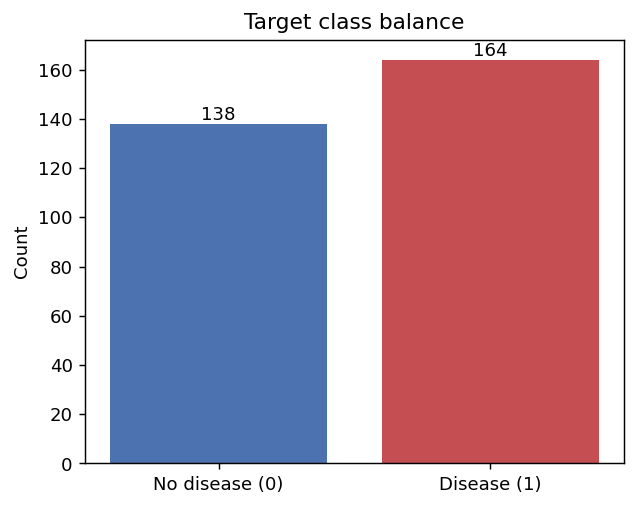

In [27]:
display(Image(plots.plot_class_balance(y)))

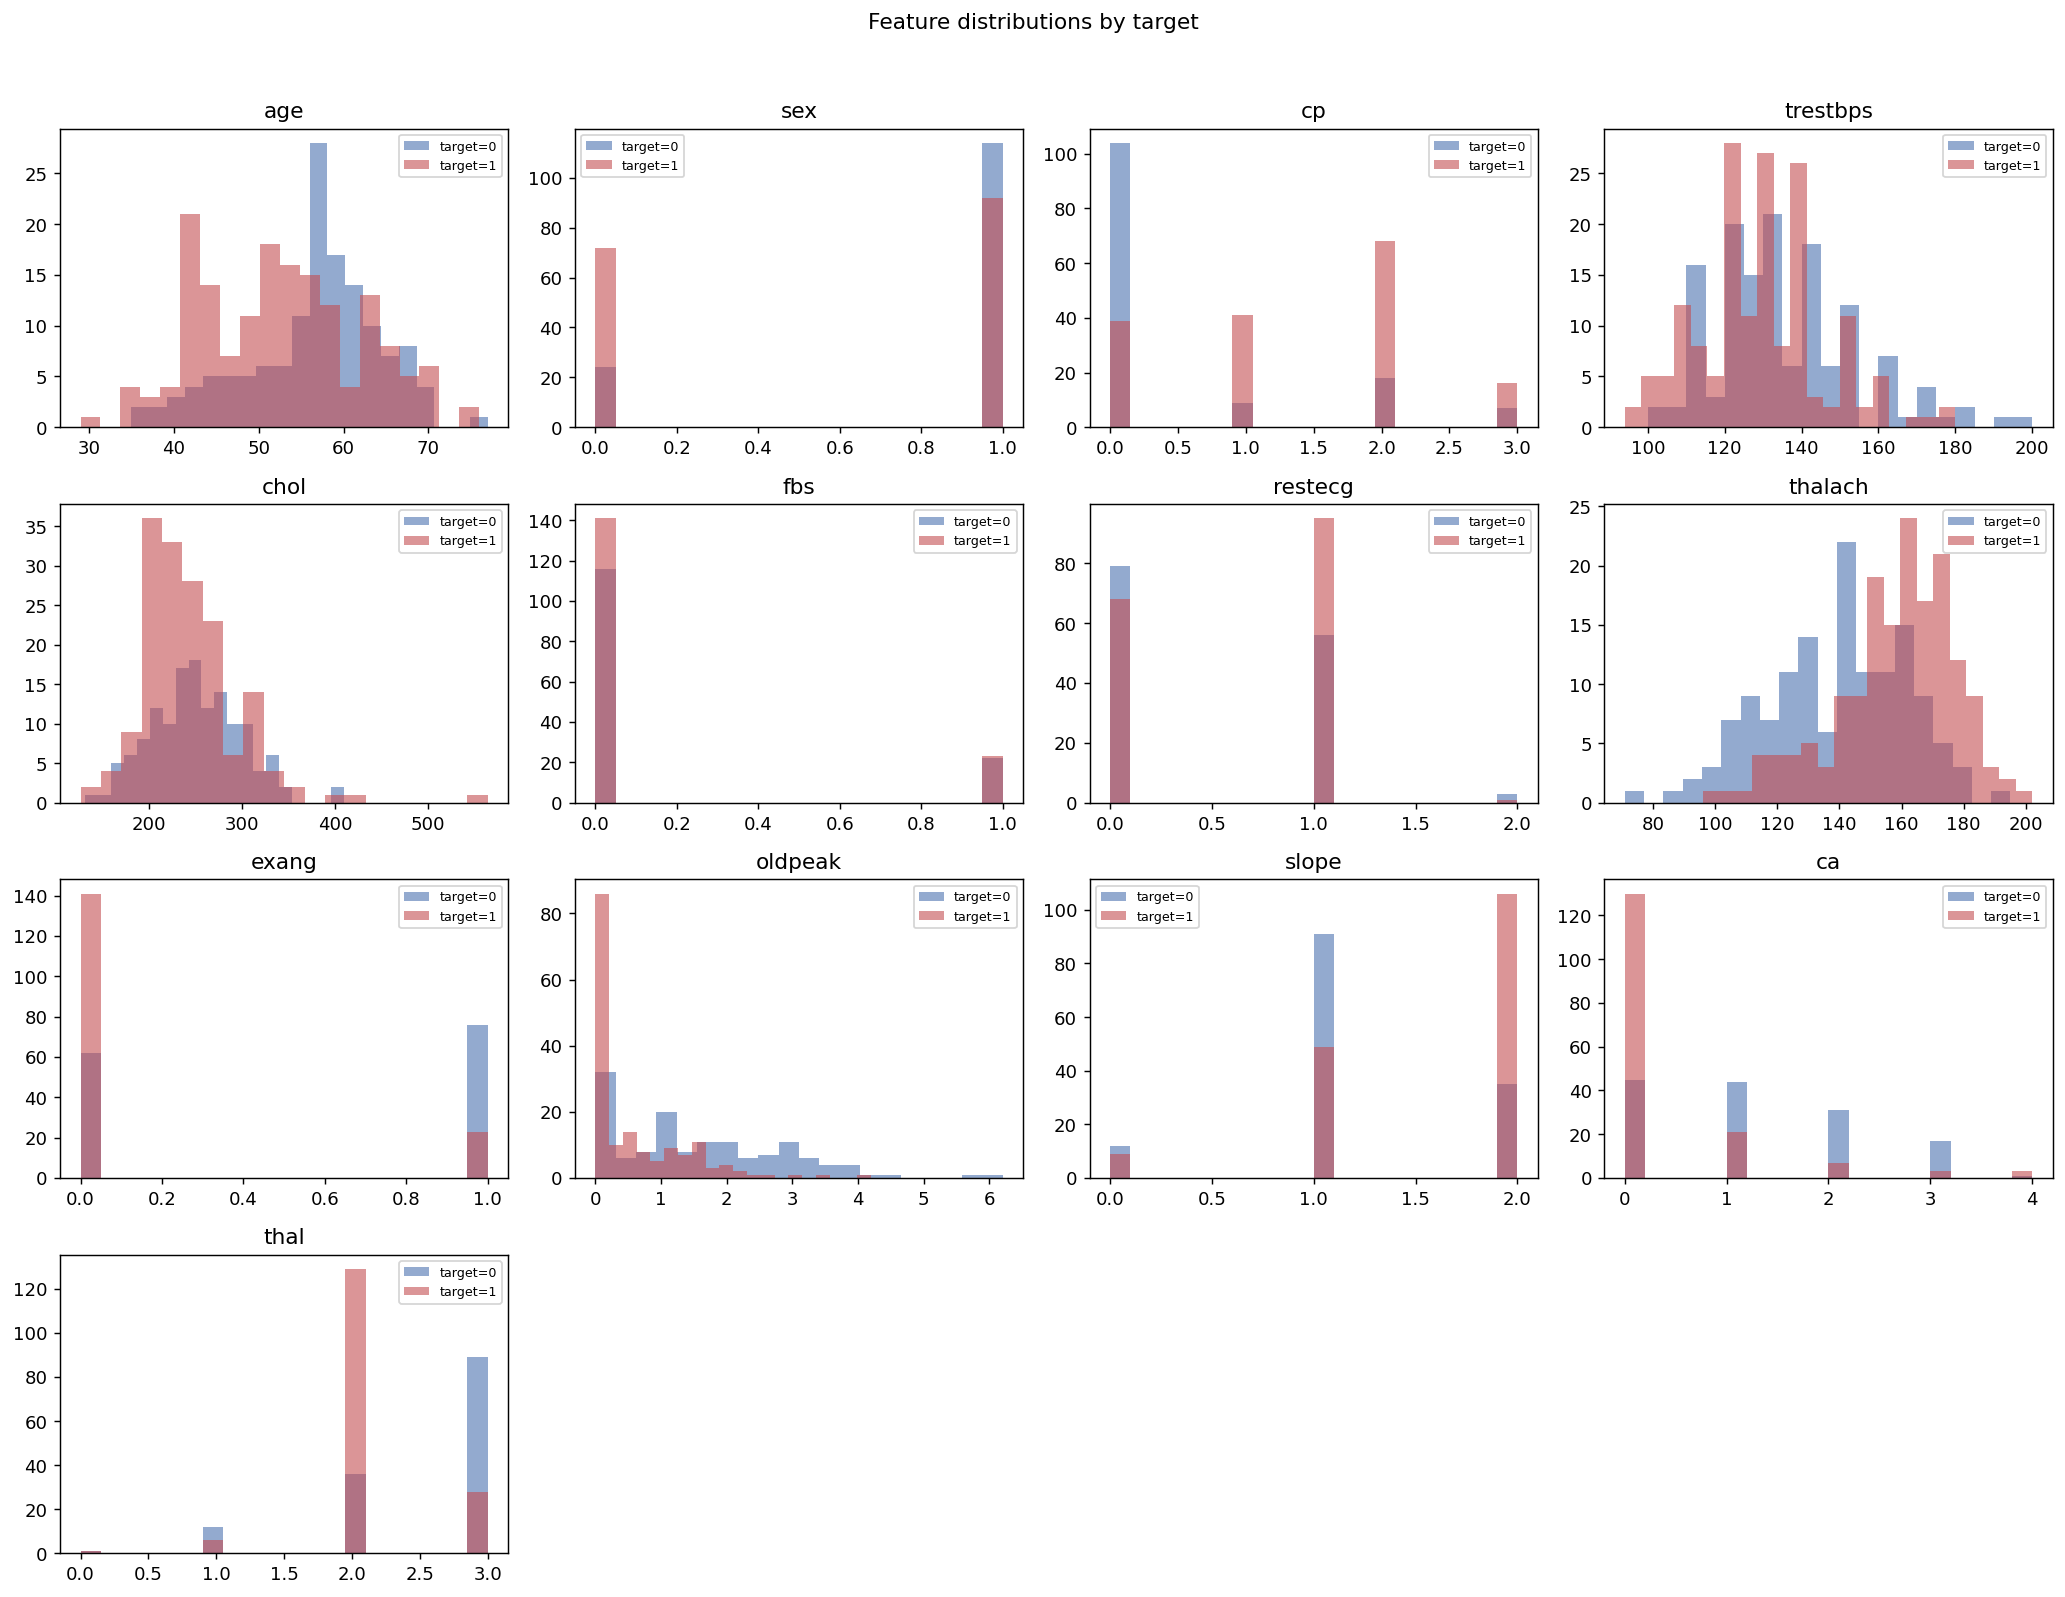

In [28]:
display(Image(plots.plot_feature_histograms(df, feature_names)))

### 3.1 Dimensionality reduction for visualization (lecture 15)

We project the data to 2-D using a **Johnson–Lindenstrauss random projection** (lecture 15).
The projection shows partial separation between the sick and healthy patients.

## 4. Main challenge: duplicates and data leakage

The Data contains 723 duplicate rows (1025 → 302)

In [29]:
X_raw, y_raw, _ = dl.get_Xy(raw_df)      # with duplicates
X_unique, y_unique, _ = dl.get_Xy(df)    # without duplicates

experiments = {
    "1-NN":                 (lambda: KNNClassifier(k=1), True),
    "5-NN":                 (lambda: KNNClassifier(k=5), True),
    "Decision Tree (full)": (lambda: DecisionTreeClassifier(max_depth=None), False),
    "Decision Tree (d=4)":  (lambda: DecisionTreeClassifier(max_depth=4), False),
    "AdaBoost (100)":       (lambda: AdaBoostClassifier(n_estimators=100), False),
    "Neural Net":           (lambda: NeuralNetwork(hidden_layers=(16,), activation="relu",
                                                   lr=0.1, epochs=300, batch_size=32,
                                                   l2=1e-4, seed=SEED), True),
}

rows = []
for name, (factory, scale) in experiments.items():
    exp = ev.duplicate_leakage_experiment(
        factory, X_raw, y_raw, X_unique, y_unique, seed=SEED, scale=scale
    )
    rows.append({
        "model":              name,
        "train (dup)":        exp["train_accuracy_with_duplicates"],
        "test (dup)":         exp["accuracy_with_duplicates"],
        "train (dedup)":      exp["train_accuracy_deduplicated"],
        "test (dedup)":       exp["accuracy_deduplicated"],
        "overfit gap":        exp["train_accuracy_deduplicated"] - exp["accuracy_deduplicated"],
        "leakage gap":        exp["accuracy_with_duplicates"] - exp["accuracy_deduplicated"],
    })

leakage_df = pd.DataFrame(rows).set_index("model")
leakage_df


,train (dup),test (dup),train (dedup),test (dedup),overfit gap,leakage gap
model,,,,,,
1-NN,1.000,1.000,1.000,0.770,0.230,0.230
5-NN,0.959,0.873,0.867,0.869,-0.002,0.004
Decision Tree (full),1.000,1.000,1.000,0.787,0.213,0.213
Decision Tree (d=4),0.849,0.820,0.859,0.770,0.088,0.049
AdaBoost (100),0.909,0.873,0.909,0.902,0.007,-0.028
Neural Net,1.000,1.000,0.992,0.754,0.238,0.246


## 5. Preprocessing and splitting

We split into train/test while preserving the class ratio (stratified) and standardize (z-score)
using the train set only. Distance/gradient-based models (k-NN, neural network) use the
standardized data; trees and AdaBoost use the original values (threshold splits are not sensitive
to scale).

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, seed=SEED, stratify=True
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train balance:", np.bincount(y_train), " Test balance:", np.bincount(y_test))

Train: (241, 13)  Test: (61, 13)
Train balance: [110 131]  Test balance: [28 33]


In [31]:
# Compare train/test accuracy with and without z-score standardization for all models.
quick_models = {
    "k-NN (k=5)":          lambda: KNNClassifier(k=5),
    "Decision Tree (d=4)": lambda: DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "AdaBoost (100)":      lambda: AdaBoostClassifier(n_estimators=100),
    "Neural Net":          lambda: NeuralNetwork(hidden_layers=(16,), activation="relu",
                                                 lr=0.1, epochs=300, batch_size=32,
                                                 l2=1e-4, seed=SEED),
}

quick_rows = []
for name, factory in quick_models.items():
    row = {"model": name}
    for label, X_fit, X_eval in [("scaled", X_train_s, X_test_s),
                                  ("raw",    X_train,   X_test)]:
        model = factory()
        model.fit(X_fit, y_train)
        tr = metrics.accuracy(y_train, model.predict(X_fit))
        te = metrics.accuracy(y_test,  model.predict(X_eval))
        row[f"train ({label})"] = tr
        row[f"test ({label})"]  = te
    quick_rows.append(row)

quick_df = pd.DataFrame(quick_rows).set_index("model")
quick_df


,train (scaled),test (scaled),train (raw),test (raw)
model,,,,
k-NN (k=5),0.867,0.869,0.772,0.705
Decision Tree (d=4),0.859,0.770,0.859,0.770
AdaBoost (100),0.909,0.902,0.909,0.902
Neural Net,0.992,0.754,0.544,0.541


## 6. Model 1 - k-Nearest Neighbors

CV accuracy per k: {1: np.float64(0.768), 3: np.float64(0.776), 5: np.float64(0.796), 7: np.float64(0.801), 9: np.float64(0.796), 11: np.float64(0.809), 15: np.float64(0.809), 21: np.float64(0.792), 31: np.float64(0.792)}
Best k = 11


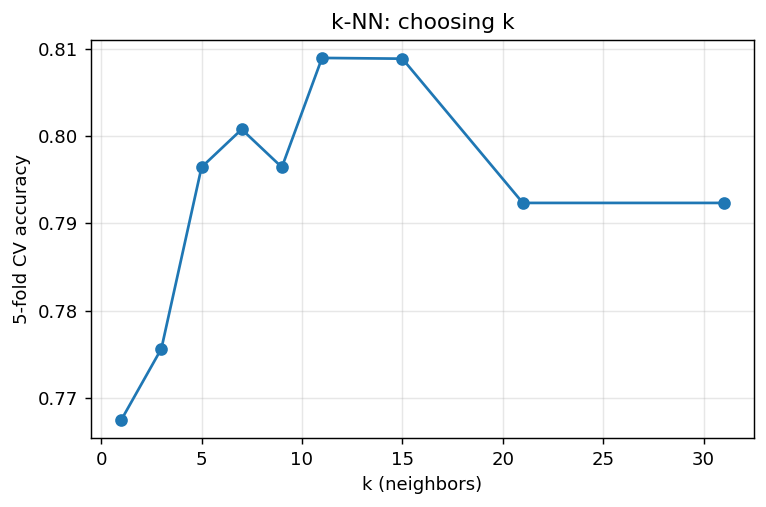

In [32]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_acc = []
for k in k_values:
    scores = ev.cross_val_score(lambda k=k: KNNClassifier(k=k), X_train, y_train,
                                n_splits=5, seed=SEED, scale=True)
    cv_acc.append(scores.mean())

best_k = k_values[int(np.argmax(cv_acc))]
print("CV accuracy per k:", {k: round(a, 3) for k, a in zip(k_values, cv_acc)})
print("Best k =", best_k)
display(Image(plots.plot_curve(k_values, cv_acc, "k (neighbors)",
            "5-fold CV accuracy", "k-NN: choosing k", name="knn_k_curve.png")))

## 7. Model 2 - Decision Tree

In [33]:

# ── Hyperparameter grid ──────────────────────────────────────────────────────
max_depths         = [3, 4, 5, 6, 7, 8]
min_samples_splits = [10, 12, 15, 18, 20, 25, 30]
min_samples_leaves = [3, 4, 5, 6, 7, 8]

total = len(max_depths) * len(min_samples_splits) * len(min_samples_leaves)

# ── Grid search (5-fold CV) ───────────────────────────────────────────────────
best_accuracy = -np.inf
best_params   = {}
done          = 0

print(f"Starting Decision Tree grid search — {total} combinations × 5 folds...")

for depth in max_depths:
    for min_split in min_samples_splits:
        for min_leaf in min_samples_leaves:

            scores = ev.cross_val_score(
                lambda d=depth, ms=min_split, ml=min_leaf:
                    DecisionTreeClassifier(max_depth=d, min_samples_split=ms, min_samples_leaf=ml),
                X_train, y_train, n_splits=5, seed=SEED, scale=False,
            )
            avg_accuracy = scores.mean()
            std_accuracy = scores.std()
            done += 1

            # On a tie, prefer the simpler model (smaller depth)
            if avg_accuracy > best_accuracy or (
                avg_accuracy == best_accuracy and depth < best_params["max_depth"]
            ):
                best_accuracy = avg_accuracy
                best_params = {
                    "max_depth":         depth,
                    "min_samples_split": min_split,
                    "min_samples_leaf":  min_leaf,
                    "cv_std":            std_accuracy,
                }
                print(f"  [{done:>3}/{total}] New best: depth={depth}, "
                      f"min_split={min_split}, min_leaf={min_leaf}  "
                      f"→ acc={avg_accuracy:.3f} ± {std_accuracy:.3f}")

            elif done % 42 == 0:
                print(f"  [{done:>3}/{total}] ...running  (current best = {best_accuracy:.3f})")

# ── Extract best parameters ───────────────────────────────────────────────────
best_depth     = best_params["max_depth"]
best_min_split = best_params["min_samples_split"]
best_min_leaf  = best_params["min_samples_leaf"]

print("-" * 50)
print(f"Grid search complete.  Best CV accuracy = {best_accuracy:.3f} ± {best_params['cv_std']:.3f}")
print(f"  max_depth:         {best_depth}")
print(f"  min_samples_split: {best_min_split}")
print(f"  min_samples_leaf:  {best_min_leaf}")

# ── Test-set accuracy for the best hyperparameters ────────────────────────────
dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
).fit(X_train, y_train)
test_acc = metrics.accuracy(y_test, dt_best.predict(X_test))
train_acc = metrics.accuracy(y_train, dt_best.predict(X_train))
print(f"\nFinal model on held-out test set:")
print(f"  Train accuracy = {train_acc:.3f}")
print(f"  Test  accuracy = {test_acc:.3f}  (overfit gap = {train_acc - test_acc:+.3f})")


Starting Decision Tree grid search — 252 combinations × 5 folds...
  [  1/252] New best: depth=3, min_split=10, min_leaf=3  → acc=0.788 ± 0.015
  [  3/252] New best: depth=3, min_split=10, min_leaf=5  → acc=0.797 ± 0.030
  [ 42/252] ...running  (current best = 0.797)
  [ 45/252] New best: depth=4, min_split=10, min_leaf=5  → acc=0.797 ± 0.039
  [ 57/252] New best: depth=4, min_split=15, min_leaf=5  → acc=0.805 ± 0.027
  [ 84/252] ...running  (current best = 0.805)
  [ 87/252] New best: depth=5, min_split=10, min_leaf=5  → acc=0.805 ± 0.047
  [ 99/252] New best: depth=5, min_split=15, min_leaf=5  → acc=0.813 ± 0.045
  [126/252] ...running  (current best = 0.813)
  [168/252] ...running  (current best = 0.813)
  [210/252] ...running  (current best = 0.813)
  [252/252] ...running  (current best = 0.813)
--------------------------------------------------
Grid search complete.  Best CV accuracy = 0.813 ± 0.045
  max_depth:         5
  min_samples_split: 15
  min_samples_leaf:  5

Final model

Baseline (all 13 features): CV acc = 0.813

  top- 1 features -> CV acc = 0.768 ± 0.053
  top- 2 features -> CV acc = 0.722 ± 0.062
  top- 3 features -> CV acc = 0.826 ± 0.025
  top- 4 features -> CV acc = 0.801 ± 0.038
  top- 5 features -> CV acc = 0.801 ± 0.038
  top- 6 features -> CV acc = 0.813 ± 0.034
  top- 7 features -> CV acc = 0.813 ± 0.034
  top- 8 features -> CV acc = 0.793 ± 0.022
  top- 9 features -> CV acc = 0.813 ± 0.043
  top-10 features -> CV acc = 0.813 ± 0.045
  top-11 features -> CV acc = 0.813 ± 0.045
  top-12 features -> CV acc = 0.813 ± 0.045
  top-13 features -> CV acc = 0.813 ± 0.045
--------------------------------------------------
Best: top-3 features -> CV acc = 0.826 (baseline = 0.813, gain = +0.012)
Selected features: ['cp', 'ca', 'slope']
Test accuracy with selected features = 0.787


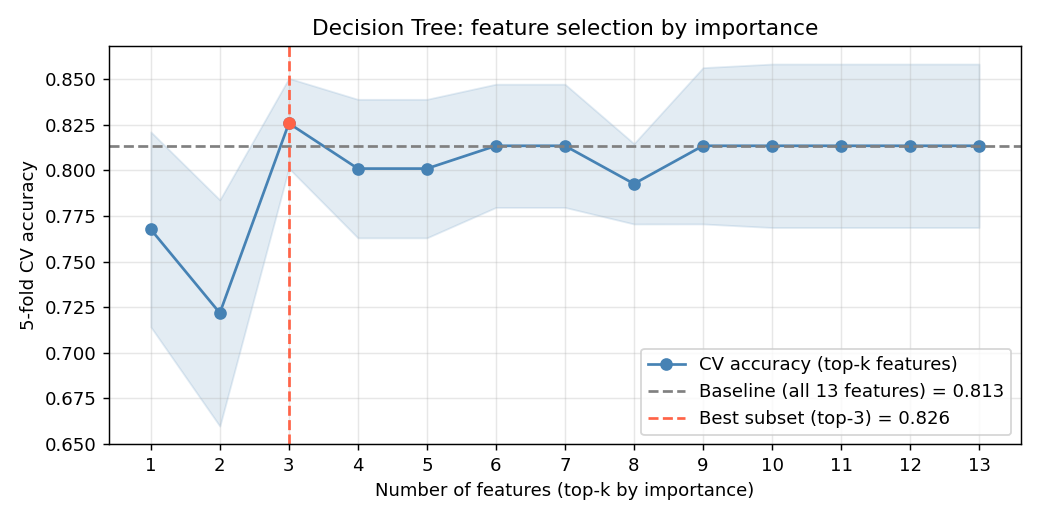

In [34]:

# ── Feature selection by importance (try to improve the Decision Tree) ────────
# Fit a tree with the tuned hyperparameters on all features to rank them.
base_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
).fit(X_train, y_train)
importance_order = np.argsort(base_tree.feature_importances_)[::-1]  # most important first

# Baseline: 5-fold CV accuracy using all features.
baseline_acc = ev.cross_val_score(
    lambda: DecisionTreeClassifier(max_depth=best_depth,
                                   min_samples_split=best_min_split,
                                   min_samples_leaf=best_min_leaf),
    X_train, y_train, n_splits=5, seed=SEED, scale=False,
).mean()
print(f"Baseline (all {X_train.shape[1]} features): CV acc = {baseline_acc:.3f}\n")

# Greedily add features in importance order; keep the subset with the best CV accuracy.
selection_results = []
for k in range(1, len(importance_order) + 1):
    cols = importance_order[:k]
    scores = ev.cross_val_score(
        lambda: DecisionTreeClassifier(max_depth=best_depth,
                                       min_samples_split=best_min_split,
                                       min_samples_leaf=best_min_leaf),
        X_train[:, cols], y_train, n_splits=5, seed=SEED, scale=False,
    )
    selection_results.append({"k": k, "cv_acc": scores.mean(), "cv_std": scores.std()})
    print(f"  top-{k:>2} features -> CV acc = {scores.mean():.3f} ± {scores.std():.3f}")

# ── Pick the best subset ──────────────────────────────────────────────────────
sel_df = pd.DataFrame(selection_results)
best_n_feats = int(sel_df.loc[sel_df["cv_acc"].idxmax(), "k"])
selected_features = importance_order[:best_n_feats]
selected_acc = sel_df["cv_acc"].max()

print("-" * 50)
print(f"Best: top-{best_n_feats} features -> CV acc = {selected_acc:.3f} "
      f"(baseline = {baseline_acc:.3f}, gain = {selected_acc - baseline_acc:+.3f})")
print("Selected features:", [feature_names[i] for i in selected_features])

# ── Final check on the held-out test set ──────────────────────────────────────
dt_selected = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
).fit(X_train[:, selected_features], y_train)
test_acc_sel = metrics.accuracy(y_test, dt_selected.predict(X_test[:, selected_features]))
print(f"Test accuracy with selected features = {test_acc_sel:.3f}")

# ── Plot CV accuracy vs number of features ────────────────────────────────────
import matplotlib.pyplot as plt

ks       = sel_df["k"].tolist()
cv_accs  = sel_df["cv_acc"].tolist()
cv_stds  = sel_df["cv_std"].tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, cv_accs, marker="o", color="steelblue", label="CV accuracy (top-k features)")
ax.fill_between(ks,
                [a - s for a, s in zip(cv_accs, cv_stds)],
                [a + s for a, s in zip(cv_accs, cv_stds)],
                alpha=0.15, color="steelblue")
ax.axhline(baseline_acc, color="gray",   linestyle="--", label=f"Baseline (all {len(ks)} features) = {baseline_acc:.3f}")
ax.axvline(best_n_feats, color="tomato", linestyle="--", label=f"Best subset (top-{best_n_feats}) = {selected_acc:.3f}")
ax.scatter([best_n_feats], [selected_acc], color="tomato", zorder=5)
ax.set_xlabel("Number of features (top-k by importance)")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Decision Tree: feature selection by importance")
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/dt_feature_selection.png", dpi=130)
plt.close(fig)
display(Image("../figures/dt_feature_selection.png"))


The overfitting curve illustrates the generalization principle from the **PAC and VC-dimension**
lectures: a deeper tree fits the train set almost perfectly (accuracy→1), but the validation
performance starts to drop — too much complexity hurts generalization.

## 8. Model 3 - AdaBoost

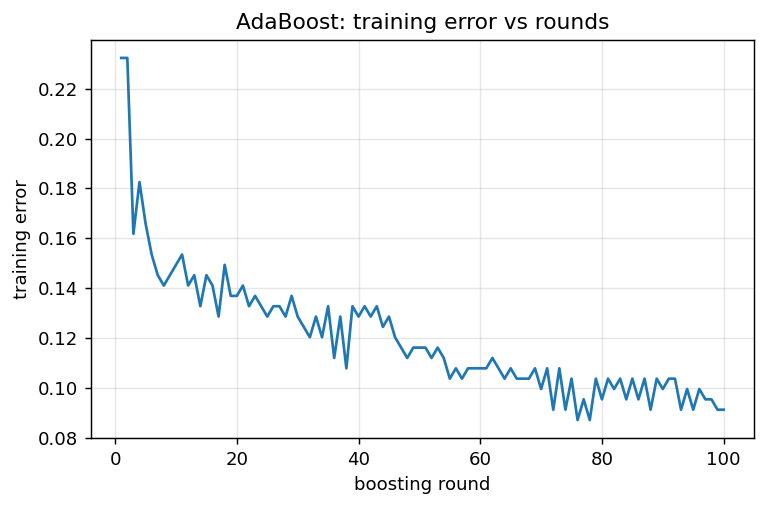

CV accuracy per n_estimators: {1: np.float64(0.768), 5: np.float64(0.788), 10: np.float64(0.805), 20: np.float64(0.793), 30: np.float64(0.793), 50: np.float64(0.784), 75: np.float64(0.772), 100: np.float64(0.768)}
Best n_estimators = 10


In [35]:
ada = AdaBoostClassifier(n_estimators=100).fit(X_train, y_train)
display(Image(plots.plot_curve(range(1, len(ada.train_errors_) + 1),
            ada.train_errors_, "boosting round", "training error",
            "AdaBoost: training error vs rounds", name="adaboost_rounds.png",
            marker="")))

# Choose the number of rounds by 5-fold CV.
round_grid = [1, 5, 10, 20, 30, 50, 75, 100]
cv_round = []
for n_rounds in round_grid:
    scores = ev.cross_val_score(lambda n=n_rounds: AdaBoostClassifier(n_estimators=n),
                                X_train, y_train, n_splits=5, seed=SEED, scale=False)
    cv_round.append(scores.mean())
best_n_rounds = round_grid[int(np.argmax(cv_round))]
print("CV accuracy per n_estimators:", {n: round(acc, 3) for n, acc in zip(round_grid, cv_round)})
print("Best n_estimators =", best_n_rounds)

The AdaBoost training-error bound from lecture 8 is $\prod_t 2\sqrt{\epsilon_t(1-\epsilon_t)}$,
so the training error decreases (almost) monotonically with the number of rounds — as the curve shows.

## 9. Model 4 - Neural Network

Numerical gradient check (relative diff) = 5.02e-10  -> PASS
hidden_layers    lr    l2  cv_acc  cv_std
        (64,) 0.100 0.000   0.801   0.051
     (32, 16) 0.100 0.000   0.793   0.013
         (8,) 0.100 0.000   0.780   0.066
        (32,) 0.100 0.000   0.780   0.049
        (16,) 0.100 0.000   0.772   0.054
        (16,) 0.100 0.001   0.772   0.054
        (16,) 0.100 0.000   0.772   0.054
      (16, 8) 0.100 0.000   0.764   0.075
        (16,) 0.010 0.000   0.759   0.062

Best params: {'hidden_layers': (8,), 'lr': 0.1, 'l2': 0.0001}
Best CV accuracy = 0.780 ± 0.066

Stopped at epoch 87  (best epoch = 66)
Final training loss = 0.2479
Test accuracy       = 0.836


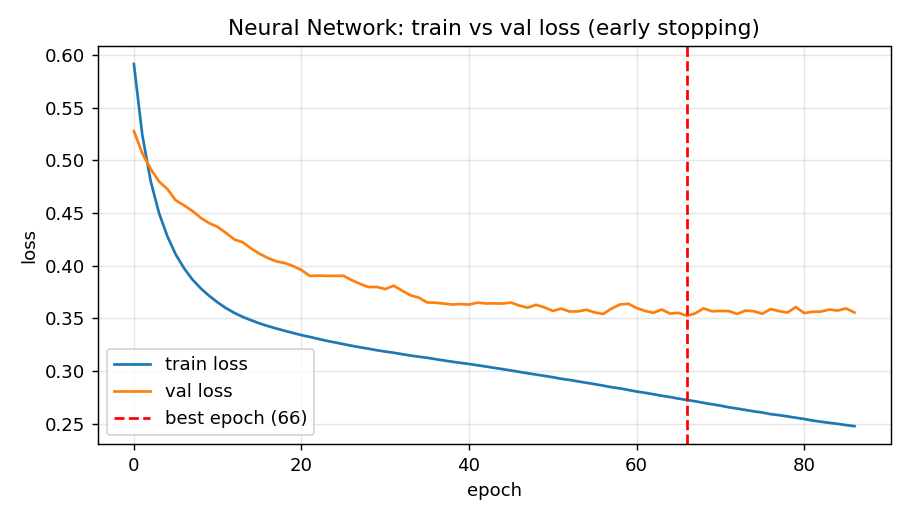

In [36]:
# Verify back-propagation with a numerical gradient check.
grad_diff = NeuralNetwork(hidden_layers=(8,), seed=0).gradient_check(X_train_s[:20], y_train[:20])
print(f"Numerical gradient check (relative diff) = {grad_diff:.2e}  -> {'PASS' if grad_diff < 1e-5 else 'FAIL'}")

# Hyperparameter search over architecture, learning rate, and L2 regularization.
param_grid = [
    {"hidden_layers": (8,),      "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (16,),     "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (32,),     "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (64,),     "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (16, 8),   "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (32, 16),  "lr": 0.1,  "l2": 1e-4},
    {"hidden_layers": (16,),     "lr": 0.01, "l2": 1e-4},
    {"hidden_layers": (16,),     "lr": 0.1,  "l2": 1e-3},
    {"hidden_layers": (16,),     "lr": 0.1,  "l2": 1e-5},
]

nn_cv_results = []
for params in param_grid:
    scores = ev.cross_val_score(
        lambda p=params: NeuralNetwork(hidden_layers=p["hidden_layers"], activation="relu",
                                       lr=p["lr"], epochs=500, batch_size=32,
                                       l2=p["l2"], seed=SEED,
                                       patience=20, val_fraction=0.1),
        X_train_s, y_train, n_splits=5, seed=SEED, scale=False
    )
    nn_cv_results.append({**params, "cv_acc": scores.mean(), "cv_std": scores.std()})

nn_cv_df = pd.DataFrame(nn_cv_results).sort_values("cv_acc", ascending=False)
nn_cv_df["hidden_layers"] = nn_cv_df["hidden_layers"].astype(str)
print(nn_cv_df.to_string(index=False))

# Selection: best cv_acc; ties broken by complexity then cv_std.
best_acc  = max(r["cv_acc"] for r in nn_cv_results)
threshold = best_acc - min(r["cv_std"] for r in nn_cv_results if r["cv_acc"] == best_acc)
candidates = [r for r in nn_cv_results if r["cv_acc"] >= threshold]
def model_complexity(r):
    return (sum(r["hidden_layers"]), r["cv_std"])
best_nn_params = min(candidates, key=model_complexity)

print("\nBest params:", {k: v for k, v in best_nn_params.items() if k not in ("cv_acc", "cv_std")})
print("Best CV accuracy = %.3f ± %.3f" % (best_nn_params["cv_acc"], best_nn_params["cv_std"]))

# Train final network with early stopping (up to 500 epochs, stop if no val improvement for 20).
nn = NeuralNetwork(hidden_layers=best_nn_params["hidden_layers"], activation="relu",
                   lr=best_nn_params["lr"], epochs=500, batch_size=32,
                   l2=best_nn_params["l2"], seed=SEED,
                   patience=20, val_fraction=0.1)
nn.fit(X_train_s, y_train)
print(f"\nStopped at epoch {len(nn.loss_history_)}  (best epoch = {nn.best_epoch_})")
print("Final training loss = %.4f" % nn.loss_history_[-1])
print("Test accuracy       = %.3f" % metrics.accuracy(y_test, nn.predict(X_test_s)))

# Plot train and validation loss together to visualise early stopping.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nn.loss_history_,     label="train loss")
ax.plot(nn.val_loss_history_, label="val loss")
ax.axvline(nn.best_epoch_, color="red", linestyle="--", label=f"best epoch ({nn.best_epoch_})")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Neural Network: train vs val loss (early stopping)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/nn_loss_curve.png", dpi=130)
plt.close(fig)
display(Image("../figures/nn_loss_curve.png"))


## 10. Model comparison (research question 2)

In [37]:

# Final tuned models — Decision Tree uses the selected feature subset from cell above.
final_models = {
    "k-NN":          (lambda: KNNClassifier(k=best_k), True, None),
    "Decision Tree": (lambda: DecisionTreeClassifier(max_depth=best_depth,
                                                      min_samples_split=best_min_split,
                                                      min_samples_leaf=best_min_leaf), False, selected_features),
    "AdaBoost":      (lambda: AdaBoostClassifier(n_estimators=best_n_rounds), False, None),
    "Neural Net":    (lambda: NeuralNetwork(hidden_layers=best_nn_params["hidden_layers"],
                                            activation="relu",
                                            lr=best_nn_params["lr"], epochs=500,
                                            batch_size=32, l2=best_nn_params["l2"],
                                            seed=SEED, patience=20, val_fraction=0.1), True, None),
}

results = {}
fitted = {}
for name, (factory, scale, cols) in final_models.items():
    X_fit, X_eval = (X_train_s, X_test_s) if scale else (X_train, X_test)
    if cols is not None:
        X_fit, X_eval = X_fit[:, cols], X_eval[:, cols]
    model = factory()
    model.fit(X_fit, y_train)
    fitted[name] = (model, scale, cols)
    results[name] = ev.evaluate_model(model, X_fit, y_train, X_eval, y_test)

results_df = pd.DataFrame(results).T[["train_accuracy", "accuracy"]]
results_df.columns = ["train acc", "test acc"]
results_df["overfit gap"] = results_df["train acc"] - results_df["test acc"]
results_df = results_df.sort_values("test acc", ascending=False)

results_df


,train acc,test acc,overfit gap
k-NN,0.855,0.885,-0.030
Neural Net,0.876,0.836,0.039
Decision Tree,0.838,0.787,0.051
AdaBoost,0.851,0.787,0.064


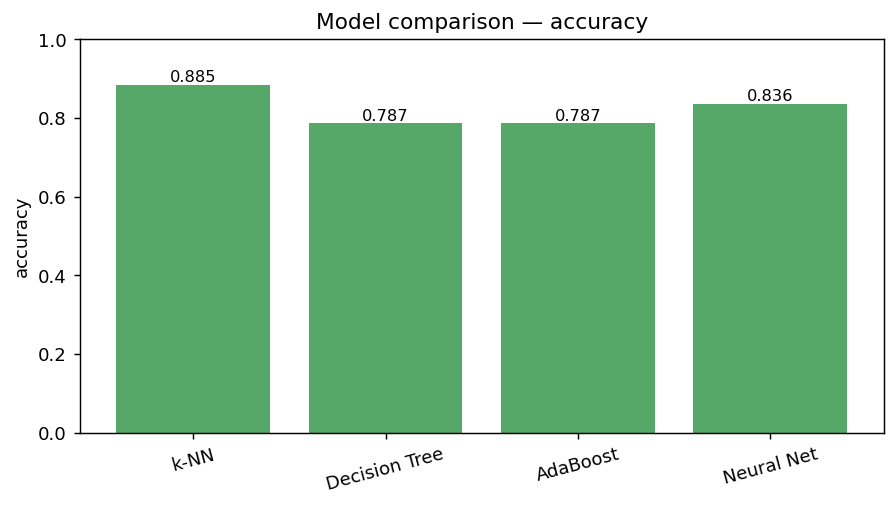

Best model: k-NN (test acc = 0.885, train acc = 0.855)


In [38]:
display(Image(plots.plot_model_comparison(results, metric="accuracy")))
best_name = results_df.index[0]
print("Best model:", best_name, "(test acc = %.3f, train acc = %.3f)" % (
    results_df.loc[best_name, "test acc"], results_df.loc[best_name, "train acc"]))


## 11. Feature importance (research question 3)

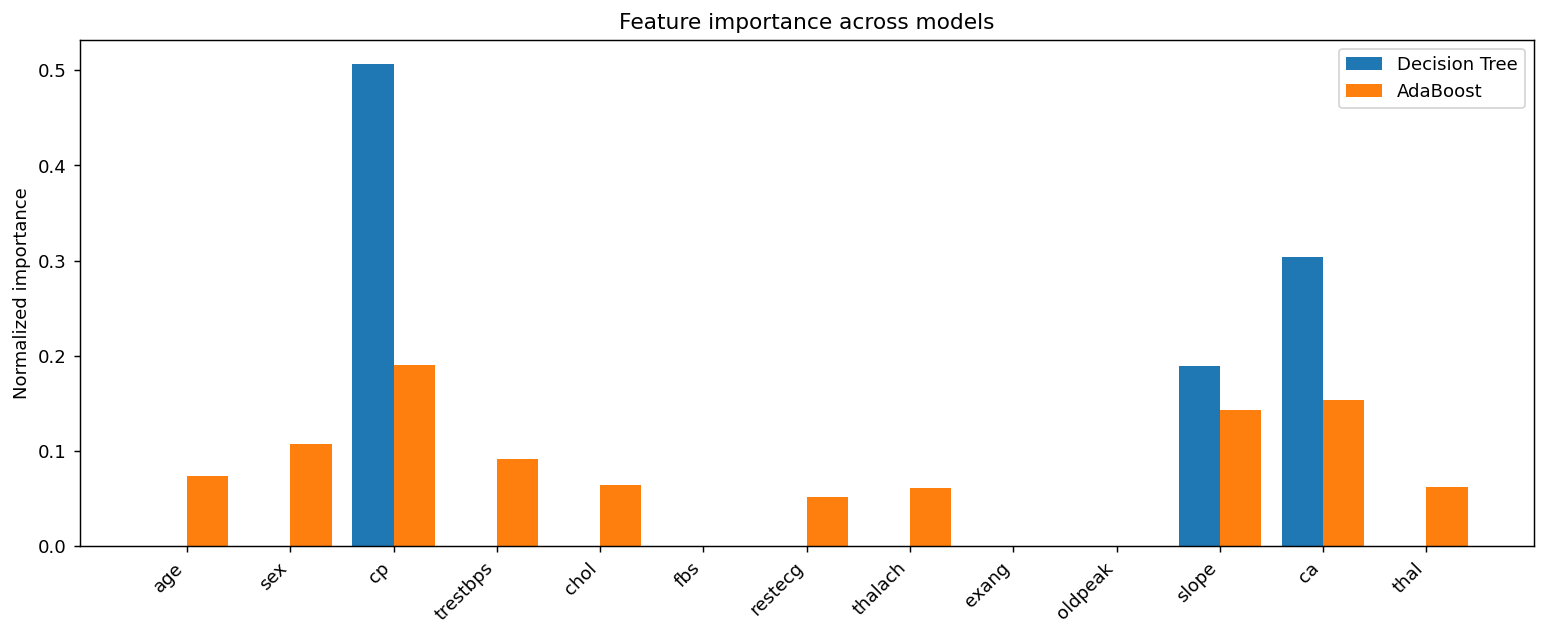

,Decision Tree,AdaBoost,mean
cp,0.507,0.190,0.348
ca,0.304,0.154,0.229
slope,0.190,0.143,0.167
sex,0.000,0.107,0.054
trestbps,0.000,0.091,0.046
age,0.000,0.074,0.037
chol,0.000,0.065,0.032
thal,0.000,0.062,0.031
thalach,0.000,0.062,0.031
restecg,0.000,0.052,0.026


In [39]:

importances = {}

# Decision Tree: fit on the selected feature subset; map importances back to all 13 features
# (unselected features get 0) so the plot axes stay consistent.
dt_sel = DecisionTreeClassifier(max_depth=best_depth,
                                min_samples_split=best_min_split,
                                min_samples_leaf=best_min_leaf).fit(X_train[:, selected_features], y_train)
dt_imp = np.zeros(len(feature_names))
dt_imp[selected_features] = dt_sel.feature_importances_
importances["Decision Tree"] = dt_imp
importances["AdaBoost"] = fitted["AdaBoost"][0].feature_importances_

display(Image(plots.plot_feature_importances(importances, feature_names)))

# Average the normalized importances across models to get a consensus.
normalized = {}
for model_name, importance in importances.items():
    importance = np.asarray(importance)
    normalized[model_name] = importance / (np.sum(np.abs(importance)) or 1)

imp_df = pd.DataFrame(normalized, index=feature_names)

imp_df["mean"] = imp_df.mean(axis=1)
imp_df.sort_values("mean", ascending=False)


## 12. Answers to the research questions

**1. Predicting heart disease.** Yes — after removing the duplicates, all models achieve accuracy
significantly above 50% (the random baseline), so heart disease can be predicted from the patient's
data at a useful level of accuracy.

**2. Comparing models.** See the results table and chart in section 10. The leading model is
identified automatically (`best_name`) by test accuracy.

**3. Feature importance.** See section 11. The features that recur as important for both models
(e.g. `cp`, `ca`, `slope`, `sex`) point to partial agreement between the methods, even though each
model weighs them slightly differently.

## 13. Challenges and lessons
- **Duplicate leakage** was the main challenge; we handled it by removing duplicates and evaluating honestly.
- **Standardization** was critical for k-NN and the neural network, and irrelevant for trees/AdaBoost.
- **Overfitting** in trees and in the number of AdaBoost rounds was controlled with cross-validation.
- **Gradient checking** in the neural network verified the correctness of the back-propagation.

The full conclusions are in the report files in the `reports/` folder.